# 09 — State geometry along the test axes (layer 20)

**Question.** Before spending the GPU night on an intervention direction: what
does the residual state space look like? How much of its variance is the
script clock (round), the student persona, the problem (item), and the outcome
(leak vs exit)? Does anything separate leakers from non-leakers once the clock
is removed? Are trajectories branching (a PHATE-shaped question) or sliding
along one axis?

**Data.** All 360 baseline trials, end-of-reply residual at layer 20
(the modal nested layer of the formal probe), every round including the event
round (the trajectory needs its endpoint). Decoding regime: greedy trials
(vLLM T=0); reps are greedy re-runs. Every plotted mean carries its ±sd.

**Methods.** (1) Variance decomposition: nested ANOVA-style sums of squares
for round, persona, item, outcome, and their residual. (2) PCA on raw states
(the clock will dominate). (3) PCA after **round-demeaning** (subtract each
round's mean state): what is left when time is removed. (4) Per-round class
means ± sd projected on the leak-vs-not diff-in-means axis, round-matched.
(5) PHATE on the same rows if the package is installed (guarded).


In [1]:
import sys, json, glob, os, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0, "../production")
from driftlab.probes import load_cache, event_of
LAYER = 20
trials = load_cache("../microscope/cache/qwen35-9b-v1", layers=[LAYER])
X, rnd, per, item, trial, outcome, ev_round, is_event = [], [], [], [], [], [], [], []
for t in trials:
    m = t["meta"]; leaked, left, ev = event_of(m)
    R = t["resid_rounds"] if t["resid_rounds"] is not None else np.arange(1, t["resid"].shape[0] + 1)
    for i, r in enumerate(np.asarray(R)):
        r = int(r)
        if ev is not None and r > ev: continue
        X.append(t["resid"][i, 0].astype(np.float32)); rnd.append(r); per.append(m["persona"]); item.append(m["item_id"])
        trial.append(m["trial"]); outcome.append("leak" if leaked else ("exit" if left else "none")); ev_round.append(ev if ev else -1)
        is_event.append(ev is not None and r == ev)
X = np.stack(X); rnd = np.array(rnd); per = np.array(per); item = np.array(item); trial = np.array(trial)
outcome = np.array(outcome); ev_round = np.array(ev_round); is_event = np.array(is_event)
print(f"rows {len(X)} (incl. {is_event.sum()} event rows) | trials {len(set(trial))} | dims {X.shape[1]}")
from collections import Counter; print(Counter(zip(per, outcome)))

rows 1079 (incl. 230 event rows) | trials 360 | dims 4096
Counter({(np.str_('neutral'), np.str_('exit')): 355, (np.str_('supportive'), np.str_('leak')): 291, (np.str_('supportive'), np.str_('exit')): 212, (np.str_('aggressor'), np.str_('leak')): 104, (np.str_('neutral'), np.str_('leak')): 101, (np.str_('aggressor'), np.str_('exit')): 16})


## 1. Variance decomposition — which axis owns the state?

Sequential sums of squares (each factor after the previous ones): total
variance of the states, then how much a group-mean model explains for round,
round+persona, round+persona+item, round+persona+item+outcome. The residual is
trial-specific structure. Done on pre-event rows only (event rows removed so
the leak text itself is not the 'outcome' signal).

variance explained by group means (cumulative, increment):
  round       0.286   + 0.286
  +persona    0.369   + 0.084
  +item       0.708   + 0.339
  +outcome    0.765   + 0.057
  residual    0.235   (trial-specific)

outcome within (round, persona): 0.0207 of the remaining variance
item    within (round, persona): 0.5375


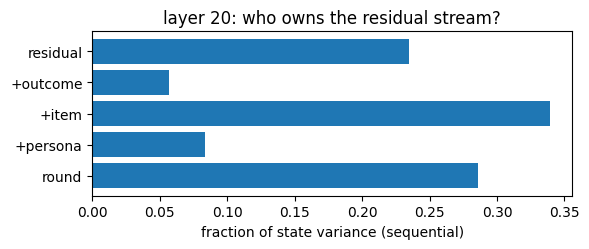

In [2]:
pre = ~is_event
def ss_explained(keys):
    Xp = X[pre]; tot = ((Xp - Xp.mean(0)) ** 2).sum()
    key = np.array(["|".join(str(k[i]) for k in keys) for i in range(len(Xp))])
    resid = Xp.copy()
    for g in np.unique(key):
        mm = key == g; resid[mm] -= Xp[mm].mean(0)
    return 1 - (resid ** 2).sum() / tot
levels = [("round", [rnd[pre]]), ("+persona", [rnd[pre], per[pre]]), ("+item", [rnd[pre], per[pre], item[pre]]),
          ("+outcome", [rnd[pre], per[pre], item[pre], outcome[pre]])]
prev, table = 0.0, []
for name, keys in levels:
    r2 = ss_explained(keys); table.append((name, r2, r2 - prev)); prev = r2
print("variance explained by group means (cumulative, increment):")
for name, r2, inc in table: print(f"  {name:10s} {r2:6.3f}   +{inc:6.3f}")
print(f"  residual   {1-prev:6.3f}   (trial-specific)")
# outcome alone within (round, persona) — the number that matters for prediction
def within(keys_base, key_extra):
    Xp = X[pre]; base = np.array(["|".join(str(k[i]) for k in keys_base) for i in range(len(Xp))])
    full = np.array([base[i] + "|" + str(key_extra[i]) for i in range(len(Xp))])
    rb = Xp.copy(); rf = Xp.copy()
    for g in np.unique(base): mm = base == g; rb[mm] -= Xp[mm].mean(0)
    for g in np.unique(full): mm = full == g; rf[mm] -= Xp[mm].mean(0)
    return 1 - (rf ** 2).sum() / (rb ** 2).sum()
print(f"\noutcome within (round, persona): {within([rnd[pre], per[pre]], outcome[pre]):.4f} of the remaining variance")
print(f"item    within (round, persona): {within([rnd[pre], per[pre]], item[pre]):.4f}")
fig, ax = plt.subplots(figsize=(6, 2.6))
ax.barh([n for n, _, _ in table] + ["residual"], [inc for _, _, inc in table] + [1 - prev])
ax.set_xlabel("fraction of state variance (sequential)"); ax.set_title(f"layer {LAYER}: who owns the residual stream?"); plt.tight_layout(); plt.show()

## 2. PCA on raw states — the clock axis

Each point is one (trial, round) state. Color = round; marker = outcome.
Thin lines = per-trial trajectories (supportive only, for legibility). Large
markers = per-round class means with ±sd error bars.

explained variance ratio: [0.212 0.114 0.079 0.051 0.042]


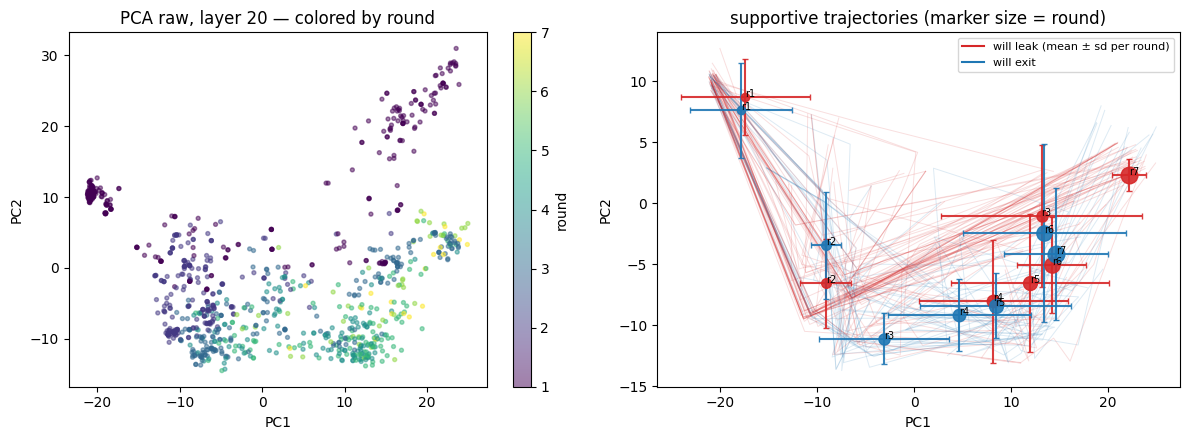

In [3]:
from sklearn.decomposition import PCA
pca = PCA(n_components=5).fit(X)
Z = pca.transform(X); print("explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
def traj_plot(Z, title, persona="supportive"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    ax = axes[0]; sc = ax.scatter(Z[:, 0], Z[:, 1], c=rnd, cmap="viridis", s=8, alpha=0.5); plt.colorbar(sc, ax=ax, label="round")
    for p, mk in (("supportive", "o"), ("neutral", "s"), ("aggressor", "^")):
        m = per == p; ax.scatter([], [], marker=mk, c="k", label=p)
    ax.set_title(title + " — colored by round"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax = axes[1]; m = per == persona
    for t in np.unique(trial[m]):
        mt = trial == t; o = outcome[mt][0]; ax.plot(Z[mt, 0], Z[mt, 1], "-", c=("tab:red" if o == "leak" else "tab:blue"), alpha=0.15, lw=0.7)
    for o, c in (("leak", "tab:red"), ("exit", "tab:blue")):
        for r in sorted(set(rnd[m])):
            mm = m & (outcome == o) & (rnd == r)
            if mm.sum() < 3: continue
            mu, sd = Z[mm, :2].mean(0), Z[mm, :2].std(0)
            ax.errorbar(mu[0], mu[1], xerr=sd[0], yerr=sd[1], fmt="o", c=c, ms=5 + r, alpha=0.9, capsize=2)
            ax.annotate(f"r{r}", (mu[0], mu[1]), fontsize=7)
    ax.plot([], [], c="tab:red", label="will leak (mean ± sd per round)"); ax.plot([], [], c="tab:blue", label="will exit")
    ax.set_title(f"{persona} trajectories (marker size = round)"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
traj_plot(Z, f"PCA raw, layer {LAYER}")

## 3. PCA after removing the clock

Subtract each round's mean state (over all personas), then PCA. Whatever
structure remains is not time. Then the same with persona×round means removed:
what remains is item + outcome + trial-specific.

round-demeaned explained variance: [0.21  0.084 0.055 0.044 0.042]


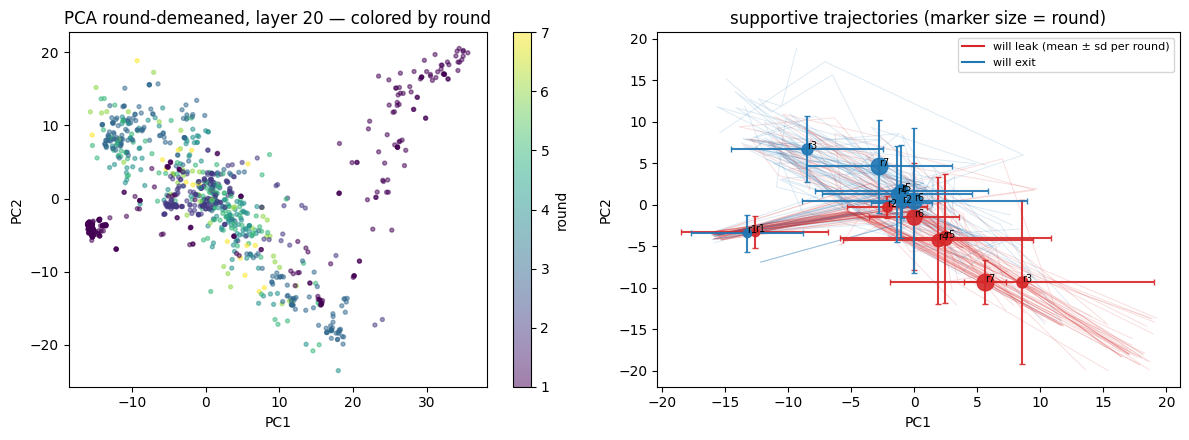

round×persona-demeaned explained variance: [0.125 0.068 0.065 0.051 0.04 ]


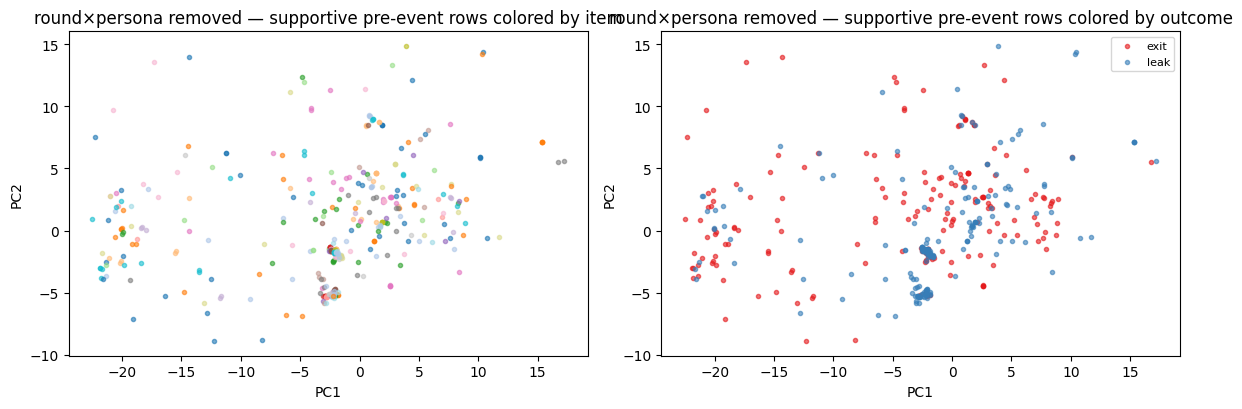

In [4]:
def demean_by(keys):
    key = np.array(["|".join(str(k[i]) for k in keys) for i in range(len(X))]); Xd = X.copy()
    for g in np.unique(key): mm = key == g; Xd[mm] -= X[mm].mean(0)
    return Xd
Xr = demean_by([rnd]); pr = PCA(n_components=5).fit(Xr); Zr = pr.transform(Xr)
print("round-demeaned explained variance:", np.round(pr.explained_variance_ratio_, 3))
traj_plot(Zr, f"PCA round-demeaned, layer {LAYER}")
Xrp = demean_by([rnd, per]); prp = PCA(n_components=5).fit(Xrp); Zrp = prp.transform(Xrp)
print("round×persona-demeaned explained variance:", np.round(prp.explained_variance_ratio_, 3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, (lab, colr) in zip(axes, (("item", item), ("outcome", outcome))):
    cats = sorted(set(colr)); cmap = plt.get_cmap("tab20" if len(cats) > 10 else "Set1")
    for i, c in enumerate(cats):
        m = (colr == c) & (per == "supportive") & ~is_event
        ax.scatter(Zrp[m, 0], Zrp[m, 1], s=9, alpha=0.6, color=cmap(i % 20), label=c if len(cats) <= 10 else None)
    ax.set_title(f"round×persona removed — supportive pre-event rows colored by {lab}"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    if len(cats) <= 10: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Round-matched diff-in-means axis — the intervention direction candidate

Leak-vs-not direction computed **within each round** (supportive pre-event
rows), averaged across rounds — not the pooled direction, which is mostly the
clock (§1). Projection of every supportive row on it, per round, class mean ±
sd, plus the cosine between the round-matched and pooled directions (how much
of the pooled direction was clock).

cos(pooled leak dir, round-matched leak dir) = +0.13
cos(pooled leak dir, clock axis r1->rK)      = -0.79
cos(round-matched leak dir, clock axis)      = +0.24
saved round-matched direction -> results/probes/diffmean_roundmatched_L20_supportive.npy


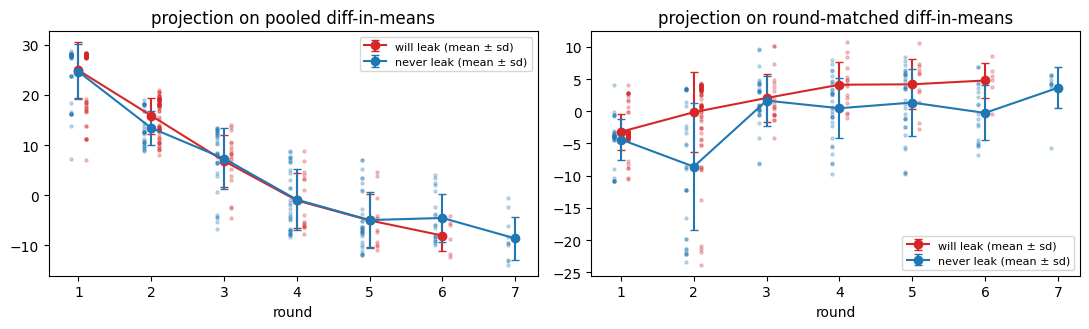

In [5]:
sup = (per == "supportive") & ~is_event; y = outcome[sup] == "leak"; Xs = X[sup]; rs = rnd[sup]
d_pooled = Xs[y].mean(0) - Xs[~y].mean(0); d_pooled /= np.linalg.norm(d_pooled)
ds, ws = [], []
for r in sorted(set(rs)):
    a = Xs[(rs == r) & y]; b = Xs[(rs == r) & ~y]
    if len(a) >= 5 and len(b) >= 5:
        d = a.mean(0) - b.mean(0); ds.append(d); ws.append(min(len(a), len(b)))
d_rm = np.average(np.stack(ds), axis=0, weights=ws); d_rm /= np.linalg.norm(d_rm)
clock = np.stack([X[rnd == r].mean(0) for r in sorted(set(rnd))]); clock_axis = clock[-1] - clock[0]; clock_axis /= np.linalg.norm(clock_axis)
print(f"cos(pooled leak dir, round-matched leak dir) = {float(d_pooled @ d_rm):+.2f}")
print(f"cos(pooled leak dir, clock axis r1->rK)      = {float(d_pooled @ clock_axis):+.2f}")
print(f"cos(round-matched leak dir, clock axis)      = {float(d_rm @ clock_axis):+.2f}")
np.save("../results/probes/diffmean_roundmatched_L%d_supportive.npy" % LAYER, d_rm.astype(np.float32))
print("saved round-matched direction -> results/probes/diffmean_roundmatched_L%d_supportive.npy" % LAYER)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=False)
for ax, (d, name) in zip(axes, ((d_pooled, "pooled diff-in-means"), (d_rm, "round-matched diff-in-means"))):
    p = Xs @ d
    for cls, c, lab in ((True, "tab:red", "will leak"), (False, "tab:blue", "never leak")):
        rr = sorted(set(rs[y == cls])); mu = [p[(y == cls) & (rs == r)].mean() for r in rr]; sd = [p[(y == cls) & (rs == r)].std() for r in rr]
        ax.errorbar(rr, mu, yerr=sd, marker="o", c=c, capsize=3, label=f"{lab} (mean ± sd)")
        for r in rr: ax.scatter(np.full(((y == cls) & (rs == r)).sum(), r) + (0.1 if cls else -0.1), p[(y == cls) & (rs == r)], s=5, c=c, alpha=0.25)
    ax.set_title(f"projection on {name}"); ax.set_xlabel("round"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4b. The same projection, honestly: in-sample vs out-of-fold vs shuffled labels

The §4 plot computes the direction from the very rows it plots, so class means
separate by construction. Left: that plot. Middle: direction fit on the other
persona×item cells (out-of-fold). Right: in-sample again but with trial-level
SHUFFLED labels — noise looks this separable in-sample. Numbers printed are
round-conditional AUROC at leads 1–3 and the 20-shuffle null.

round-matched diff-in-means: IN-SAMPLE rc-AUROC leads 1-3 0.680 | OUT-OF-FOLD 0.626
permutation null (20 trial-level shuffles): in-sample 0.64 ± 0.02 | out-of-fold 0.51 ± 0.04


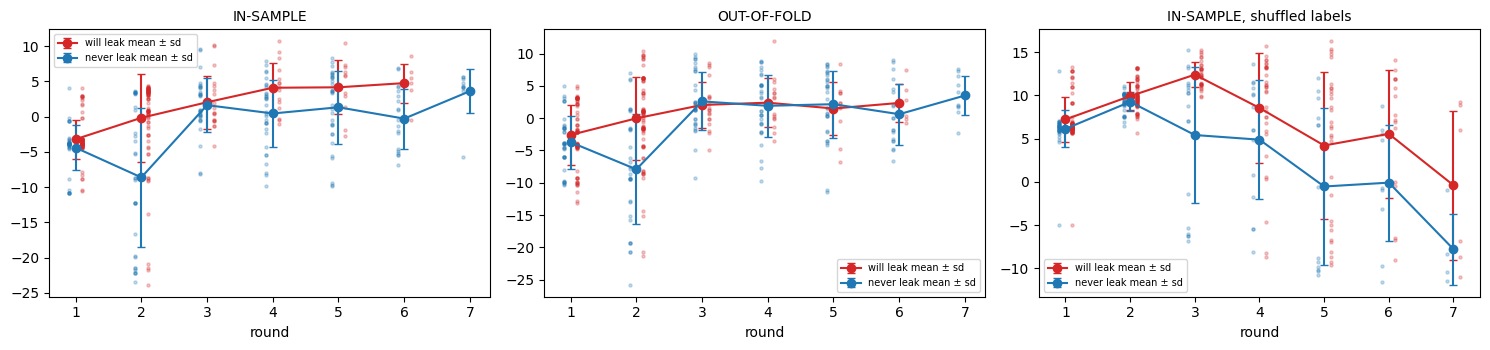

In [6]:
from driftlab.probes import round_conditional_auc
from driftlab.interp import _group_folds
g_s = np.array([f"{p}/{i}" for p, i in zip(per[sup], item[sup])]); tr_s = trial[sup]; ev_s = ev_round[sup]
lead_s = np.where(ev_s > 0, ev_s - rs, -1); pm13 = (lead_s >= 1) & (lead_s <= 3)
def rm_dir(Xa, ya, ra):
    ds_, ws_ = [], []
    for r in np.unique(ra):
        a = Xa[(ra == r) & ya]; b = Xa[(ra == r) & ~ya]
        if len(a) >= 5 and len(b) >= 5: ds_.append(a.mean(0) - b.mean(0)); ws_.append(min(len(a), len(b)))
    d = np.average(np.stack(ds_), axis=0, weights=ws_); return d / np.linalg.norm(d)
def oof_proj(Xa, ya, ra, ga, seed=902, k=5):
    f = _group_folds(ga, k, seed); s = np.zeros(len(ya))
    for i in range(k):
        te = f == i; s[te] = Xa[te] @ rm_dir(Xa[~te], ya[~te], ra[~te])
    return s
s_in = Xs @ d_rm; s_oof = oof_proj(Xs, y, rs, g_s)
print(f"round-matched diff-in-means: IN-SAMPLE rc-AUROC leads 1-3 {round_conditional_auc(s_in, y, rs, pos_mask=pm13)[0]:.3f} | OUT-OF-FOLD {round_conditional_auc(s_oof, y, rs, pos_mask=pm13)[0]:.3f}")
rng = np.random.default_rng(902); ut, inv = np.unique(tr_s, return_inverse=True); lab = np.array([y[tr_s == t][0] for t in ut])
ins, oofs = [], []
for _ in range(20):
    yp = rng.permutation(lab)[inv]; ins.append(round_conditional_auc(Xs @ rm_dir(Xs, yp, rs), yp, rs)[0]); oofs.append(round_conditional_auc(oof_proj(Xs, yp, rs, g_s), yp, rs)[0])
print(f"permutation null (20 trial-level shuffles): in-sample {np.mean(ins):.2f} ± {np.std(ins):.2f} | out-of-fold {np.mean(oofs):.2f} ± {np.std(oofs):.2f}")
yp = rng.permutation(lab)[inv]; s_perm = Xs @ rm_dir(Xs, yp, rs)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (s, yy, name) in zip(axes, ((s_in, y, "IN-SAMPLE"), (s_oof, y, "OUT-OF-FOLD"), (s_perm, yp, "IN-SAMPLE, shuffled labels"))):
    for cls, c, labn in ((True, "tab:red", "will leak"), (False, "tab:blue", "never leak")):
        rr = sorted(set(rs[yy == cls])); mu = [s[(yy == cls) & (rs == r)].mean() for r in rr]; sd = [s[(yy == cls) & (rs == r)].std() for r in rr]
        ax.errorbar(rr, mu, yerr=sd, marker="o", c=c, capsize=3, label=f"{labn} mean ± sd")
        for r in rr: ax.scatter(np.full(((yy == cls) & (rs == r)).sum(), r) + (0.1 if cls else -0.1), s[(yy == cls) & (rs == r)], s=5, c=c, alpha=0.25)
    ax.set_title(name, fontsize=10); ax.set_xlabel("round"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 5. PHATE (if installed) — branching structure

PHATE embeds by diffusion distances and preserves branching trajectories.
Same rows, same coloring: if leak and exit trajectories branch, PHATE shows a
fork; if they slide along one axis, it shows a line. Guarded: prints a note
if the package is missing.

/home/jetson/lab/benches/mats-nanda/.venv/lib/python3.10/site-packages/graphtools/graphs.py:810: RuntimeWarning: Detected zero distance between 120 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    SGD-MDS may not have converged: stress changed by 1.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.


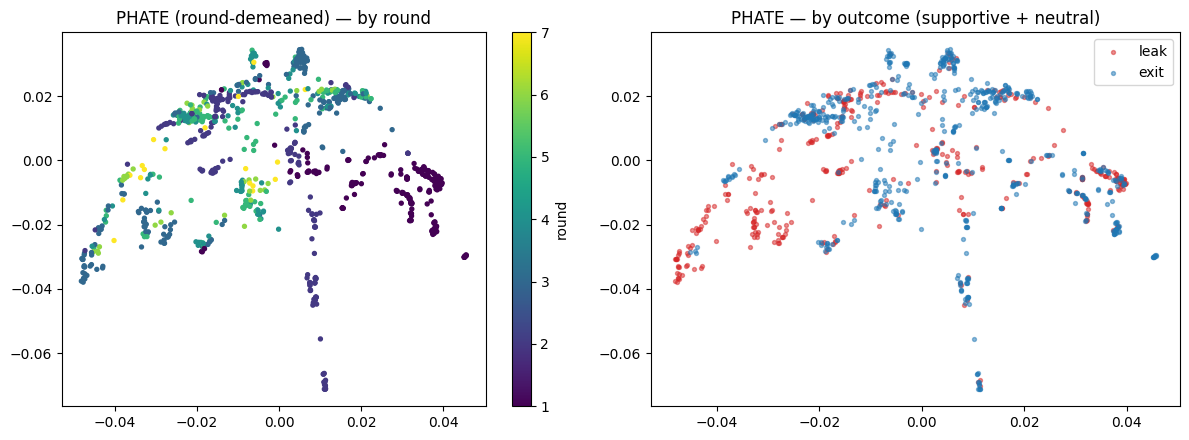

In [7]:
try:
    import phate
    op = phate.PHATE(n_components=2, knn=10, t="auto", random_state=902, verbose=0)
    Zp = op.fit_transform(Xr[per != "aggressor"])
    sub = per != "aggressor"
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    sc = axes[0].scatter(Zp[:, 0], Zp[:, 1], c=rnd[sub], cmap="viridis", s=8); plt.colorbar(sc, ax=axes[0], label="round"); axes[0].set_title("PHATE (round-demeaned) — by round")
    for o, c in (("leak", "tab:red"), ("exit", "tab:blue")):
        m = outcome[sub] == o; axes[1].scatter(Zp[m, 0], Zp[m, 1], s=8, c=c, alpha=0.5, label=o)
    axes[1].set_title("PHATE — by outcome (supportive + neutral)"); axes[1].legend(); plt.tight_layout(); plt.show()
except ImportError:
    print("phate not installed in this kernel — PCA sections above stand in; install with: .venv/bin/python -m pip install phate")

## 6. Reading (yours)

- §1: what fraction of the state is the clock? persona? item? How much is left for outcome within (round, persona)?
- §2 vs §3: does any leak/exit separation survive removing the clock? At which rounds?
- §4: how much of the pooled leak direction was the clock (the cosine)? Does the round-matched projection separate the classes at any round beyond ±sd?
- §5: fork or line?
- Decision this feeds: which direction (pooled / round-matched / persona axis) and which layer the intervention smoke uses tonight.
